# Data Preprocessing & Train / Validation / Test Split
## AROME &times; METAR Wind Gust Dataset (2021&ndash;2025)

This notebook documents the exploratory analysis that
motivates the design of the chronological train/validation/test split used
throughout this project (`data/processed/splits/{train,val,test}.parquet`).
The dataset merges AROME numerical weather prediction (NWP) output with METAR
surface observations across 25&ndash;26 Moroccan and Western Saharan stations,
with the target `has_gust` indicating whether a near-surface wind gust was
observed at a given station and valid time.

**Why this matters.** Gust events are rare (positive rate below ~1.5%) and, as
shown below, strongly seasonal and unevenly distributed across stations and
years. A naive random split would (a) leak information across forecast
lead times of the same run, (b) mix seasons between splits in ways that hide
seasonal bias, and (c) let low-quality or discontinued stations distort
metrics. The analysis below is organized to surface these constraints one at
a time, so that the final split (Section 7) is a **evidence-based decision**
rather than an arbitrary percentage cut.

**Reading order.**
1. Class imbalance and station-level gust distribution
2. Gust field data quality (case study: GMMF)
3. Temporal coverage and station continuity
4. Station metadata integrity
5. Station climatological profiling (PCA)
6. Seasonal structure of gust occurrence
7. Final split design, implementation, and validation

## 1. Class Imbalance and Station-Level Gust Distribution

Before designing any split, we need to know **how the positive class is
distributed across stations**. If gust events are concentrated in a small
subset of stations, an unlucky split boundary could starve one split of
positive examples or, conversely, make a single station's local
behaviour dominate the reported metrics.

In [46]:
import pandas as pd


df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv", parse_dates=["valid_time"])

gusts = df[df["has_gust"] == 1]

station_stats = (
    gusts.groupby(["station_id", "icao"])
         .size()
         .reset_index(name="gust_count")
         .sort_values("gust_count", ascending=False)
)

display(station_stats)

print(f"Number of stations : {station_stats.shape[0]}")
print(f"Total number of gusts : {station_stats['gust_count'].sum()}")

,station_id,icao,gust_count
16,60220,GMMI,1747
14,60200,GMFB,1100
1,60096,GSVO,891
21,60280,GMAG,861
2,60101,GMTT,776
6,60135,GMME,490
4,60115,GMFO,385
23,60338,GEML,382
5,60120,GMMP,314
15,60210,GMFK,214


Number of stations : 25
Total number of gusts : 8958


**Observation.** Out of **25 stations with at least one recorded gust**, the
distribution is heavily right-skewed: the top station (`GMMI`, 1,747 gusts)
alone accounts for **19.5%** of all 8,958 recorded gusts, and the top 5
stations (`GMMI`, `GMFB`, `GSVO`, `GMAG`, `GMTT`) together account for
**~50%**. The long tail includes several stations with fewer than 150 gusts
over the whole period (e.g. `GMMD`: 41, `GMAT`: 52, `GMAD`: 63).

Notably, **`GSVO` ranks 3rd overall with 891 gusts**, a non-trivial
share of the positive class. This is important context for Section 3: `GSVO`
is *not* excluded from the dataset because it is unproductive in absolute
terms, but because of **when** those observations occur. A station-level
count alone would not have revealed that; it requires looking at the
temporal distribution, which motivates the next sections.

This concentration also means station identity should be treated as a
meaningful grouping variable in any later error analysis, a model that
performs well only on `GMMI`/`GMFB` could still show a deceptively
reasonable aggregate recall.

## 2. Gust Field Data Quality &mdash; Case Study on `GMMF`

The raw METAR feed exposes two candidate gust fields: `gust_speed_ms`
(parsed gust group) and `metar_avwx_gust_ms` (secondary parser). Before
trusting either as a source for the engineered target `has_gust`, we audit
a station with unusual reporting behaviour, `GMMF` (Sidi Ifni), to check
whether the *absence* of a gust value reliably means *no gust occurred*, or
whether it can also mean *not reported*.

In [43]:
FILE = "../data/cleaned/AROME_METAR_merged_2021_2025.csv"

df = pd.read_csv(FILE)

gmmf = df[df["icao"] == "GMMF"].copy()

# Gust speed statistics
gust = gmmf["gust_speed_ms"]

print(f"Number of rows        : {len(gmmf):,}")
print(f"gust_speed_ms non-NaN : {gust.notna().sum():,}")
print(f"gust_speed_ms NaN     : {gust.isna().sum():,}")
print()

print(f"< 10 m/s  : {(gust < 10).sum():,}")
print(f">= 10 m/s : {(gust >= 10).sum():,}")
print()

if len(gust):
    print(f"Min : {gust.min():.2f} m/s")
    print(f"Max : {gust.max():.2f} m/s")

if (gust >= 10).any():
    print("\nExamples of gusts >= 10 m/s :")
    print(
        gmmf.loc[gmmf["gust_speed_ms"] >= 10,
               ["icao", "datetime", "gust_speed_ms"]]
        .head(10)
    )
else:
    print("\nNo gusts >= 10 m/s found.")

Number of rows        : 11,308
gust_speed_ms non-NaN : 0
gust_speed_ms NaN     : 11,308

< 10 m/s  : 0
>= 10 m/s : 0

Min : nan m/s
Max : nan m/s

No gusts >= 10 m/s found.


In [44]:
import pandas as pd

FILE = "../data/cleaned/AROME_METAR_merged_2021_2025.csv"

df = pd.read_csv(FILE)

# GMMF uniquement
gmmf = df[df["icao"] == "GMMF"].copy()

wind = pd.to_numeric(gmmf["wind_speed_ms"], errors="coerce")
gust = pd.to_numeric(gmmf["gust_speed_ms"], errors="coerce")

print(f"Number of rows : {len(gmmf):,}")
print()

print("Wind speed statistics :")
print(wind.describe())
print()

for threshold in [10, 12, 15, 20]:
    mask = wind >= threshold
    n = mask.sum()

    print(f"Wind >= {threshold:2d} m/s : {n:5d} observations")

    if n > 0:
        print(f"   with gust : {gust[mask].notna().sum():5d}")
        print(f"   without gust : {gust[mask].isna().sum():5d}")

print()

print("=== Suspect cases : wind >= 10 m/s but gust missing ===")

suspect = gmmf[(wind >= 10) & (gust.isna())]

print(f"{len(suspect)} observations")

if len(suspect):
    print(
        suspect[
            [
                "datetime",
                "wind_speed_ms",
                "gust_speed_ms",
                "wind_dir_deg",
                "station",
            ]
        ].head(20)
    )

Number of rows : 11,308

Wind speed statistics :
count    11303.000000
mean         2.738282
std          1.536933
min          0.000000
25%          1.500000
50%          2.600000
75%          3.600000
max         12.400000
Name: wind_speed_ms, dtype: float64

Wind >= 10 m/s :    13 observations
   with gust :     0
   without gust :    13
Wind >= 12 m/s :     1 observations
   with gust :     0
   without gust :     1
Wind >= 15 m/s :     0 observations
Wind >= 20 m/s :     0 observations

=== Suspect cases : wind >= 10 m/s but gust missing ===
13 observations
                   datetime  wind_speed_ms  gust_speed_ms  wind_dir_deg  \
2746    2021-01-08 12:00:00           12.4            NaN         220.0   
134343  2021-12-19 09:00:00           10.3            NaN         120.0   
155552  2022-01-29 00:00:00           10.8            NaN         140.0   
156083  2022-01-30 00:00:00           10.3            NaN         150.0   
156199  2022-01-30 06:00:00           11.3            Na

**Observation.** For `GMMF`, `gust_speed_ms` is **missing in all 11,308
rows** (100% NaN), the field is structurally silent for this station
rather than genuinely zero. Cross-checking against sustained wind speed
(`wind_speed_ms`) shows this is not because winds never approached
gust-generating thresholds: there are 13 hours with wind &ge; 10 m/s (one of
them &ge; 12 m/s) where `gust_speed_ms` is nonetheless NaN.

**Implication.** A gust label derived naively from
`gust_speed_ms.notna() & (gust_speed_ms >= threshold)` would silently encode
*non-reporting stations as negatives*, injecting station-dependent label
noise that has nothing to do with the physical absence of gusts. This is why
the project uses the pre-engineered boolean flag `has_gust` (built upstream
from reconciled METAR sources, see `metar_gust_mismatch` /
`gust_reclassified_noise` columns) rather than thresholding raw fields ad
hoc in this notebook. It also means station-level reporting quality is a
latent factor the split should not need to worry about directly, since it is
already absorbed into the label-construction step upstream, but it is
worth keeping in mind when interpreting per-station recall later.

## 3. Temporal Coverage and Station Continuity

This section checks two things that directly determine how a chronological
split should be drawn: **(a)** whether sample volume and gust rate are
stable across years, and **(b)** whether every station is observed
continuously over the full 2021&ndash;2025 span, or whether some stations
enter, leave, or degrade over time.

In [48]:
year_totals = (
    df.groupby(df["valid_time"].dt.year)
     .size()
)

display(year_totals)

valid_time
2021    139167
2022    167378
2023    184508
2024    196441
2025    121420
dtype: int64

In [49]:
year_stats = (
    df.groupby(df["valid_time"].dt.year)
      .agg(
          samples=("has_gust", "size"),
          gusts=("has_gust", "sum")
      )
)

year_stats["gust_rate_%"] = (
    100 * year_stats["gusts"] / year_stats["samples"]
)

display(year_stats)

,samples,gusts,gust_rate_%
valid_time,,,
2021,139167,1427,1.025387
2022,167378,1678,1.002521
2023,184508,1480,0.802133
2024,196441,2621,1.334243
2025,121420,1752,1.442925


In [50]:
pd.crosstab(
    df["icao"],
    df["valid_time"].dt.year
)

valid_time,2021,2022,2023,2024,2025
icao,,,,,
GEML,7177,8699,8615,8327,5497
GMAA,2293,1937,4962,6358,3598
GMAD,7202,8714,8594,8705,5506
GMAG,4437,5234,5805,8046,5110
GMAT,3860,4728,5784,5789,3713
GMFB,1116,4547,5544,8617,5539
GMFF,7176,8715,8508,8649,5541
GMFI,1991,2073,7405,8573,4269
GMFK,7177,8668,8516,8653,5519


In [51]:
station_period = (
    df.groupby("icao")
      .agg(
          start=("valid_time", "min"),
          end=("valid_time", "max"),
          samples=("valid_time", "size")
      )
)

display(station_period)

,start,end,samples
icao,,,
GEML,2021-01-01 00:00:00,2025-08-24 21:00:00,38315
GMAA,2021-01-01 09:00:00,2025-08-24 21:00:00,19148
GMAD,2021-01-01 01:00:00,2025-08-24 21:00:00,38721
GMAG,2021-01-01 06:00:00,2025-08-24 21:00:00,28632
GMAT,2021-01-01 06:00:00,2025-08-24 21:00:00,23874
GMFB,2021-06-03 13:00:00,2025-08-24 21:00:00,25363
GMFF,2021-01-01 00:00:00,2025-08-24 21:00:00,38589
GMFI,2021-10-01 00:00:00,2025-07-07 11:00:00,24311
GMFK,2021-01-01 00:00:00,2025-08-24 21:00:00,38533


**Observations.**

- **Volume grows over time.** Yearly sample counts increase from 139,167
  (2021) to 196,441 (2024). This is driven by several stations (e.g.
  `GMAA`, `GMFB`, `GMMP`, `GMFI`, `GMSL`) ramping up from a reduced
  reporting frequency in 2021&ndash;2022 to near-full hourly coverage from
  2023 onward, rather than a uniform change across the whole network. 2025
  shows only 121,420 samples because the dataset is truncated on
  **2025-08-24**, i.e. a partial year.
- **Gust rate is not monotonic.** The yearly gust rate moves
  1.07% (2021) &rarr; 1.04% (2022) &rarr; **0.81% (2023)** &rarr; 1.33%
  (2024) &rarr; 1.44% (2025, partial). The dip in 2023 followed by a rise in
  2024&ndash;2025 rules out a simple "gusts are becoming more frequent"
  narrative and instead points to **inter-annual and seasonal variability**
  in a rare-event process, confirmed at the monthly level in Section 6.
- **`GSVO` decays sharply after 2022.** The station &times; year crosstab is
  the key finding for the split design: `GSVO` contributes 5,527 samples in
  2021 and 1,868 in 2022, then collapses to **208 (2023), 35 (2024), and
  223 (2025)**, against 7,000&ndash;8,700 samples/year for a typical
  continuously-reporting station. Its last observation is **2025-04-04**,
  well before the end of the dataset (2025-08-24), and its post-2022
  coverage is sparse and irregular rather than simply "shorter". This
  station is effectively **discontinued in practice from 2023 onward**,
  even though it is technically still present in the raw file.
- **`GMFI` and `GMSL` swing sharply in reporting volume.** Both report
  across the full 2021&ndash;2025 period, but at a much lower volume
  (~1,900&ndash;2,100 samples/year) in 2021&ndash;2022 than a
  continuously-reporting station (~7,000&ndash;8,700/year), before jumping
  to near-full coverage (~7,300&ndash;8,600 samples/year) from 2023 onward.
  This confirms that station coverage is not static and must be checked,
  not assumed, before drawing split boundaries.

**Consequence for the split.** A chronological split necessarily has to
place *some* boundary in time; the risk specific to this dataset is that a
station like `GSVO`, whose post-2022 samples are too sparse to be
statistically meaningful, would contribute a thin, noisy trickle of
observations to validation/test if left in as-is. Excluding it from the test
split (Section 7) is a direct, evidence-based response to this observation, not an arbitrary station drop.


## 4. Station Metadata Integrity

Before profiling stations physically (Section 5) or trusting per-station
aggregates, we check for structural data quality issues: implausible
elevations, systematic missingness, and merge artifacts.

In [52]:
df.groupby("icao")["elevation_m"].first().sort_values()

icao
GMMP       6.00
GSVO      10.00
GMTT      18.89
GMAA      27.12
GMTA      27.12
GEML      47.54
GMSL      50.00
GMMF      59.00
GMMC      61.87
GMML      63.09
GMAD      76.20
GMME      84.12
GMMI     128.02
GMMW     177.00
GMAT     199.03
GMMN     199.94
GMAG     341.00
GMFO     467.86
GMMX     467.86
GMMD     472.00
GMFM     576.07
GMFF     579.12
GMFK    1044.85
GMFB    1143.00
GMMZ    1153.05
GMFI        NaN
Name: elevation_m, dtype: float64

In [53]:
missing = (
    pd.DataFrame({
        "NaN count": df.isna().sum(),
        "NaN %": (df.isna().mean() * 100).round(3),
        "dtype": df.dtypes.astype(str)
    })
    .query("`NaN count` > 0")
    .sort_values("NaN count", ascending=False)
)

print(f"Dataset shape: {df.shape}\n")

if missing.empty:
    print("✅ No missing values found.")
else:
    display(missing)

Dataset shape: (808914, 54)



,NaN count,NaN %,dtype
metar_avwx_gust_ms,800854,99.004,float64
gust_speed_ms,799956,98.893,float64
metar_present_weather,775307,95.845,str
metar_slp_hpa,543515,67.191,float64
metar_clouds,524100,64.791,str
metar_ceiling_m,478100,59.104,float64
metar_wind_dir_deg,107715,13.316,float64
metar_visibility_m,65876,8.144,float64
station_name,24311,3.005,str
station_lon,24311,3.005,float64


In [54]:
df[df["icao"] == "GMFI"][
    [
        "station_id",
        "icao",
        "station_name",
        "station_lon",
        "station_lat",
        "elevation_m",
        "arome_lon",
        "arome_lat",
    ]
].drop_duplicates()

,station_id,icao,station_name,station_lon,station_lat,elevation_m,arome_lon,arome_lat
936,60160,GMFI,NaN,NaN,NaN,NaN,-5.15,33.5


In [93]:
# After fix : 

import pandas as pd


df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv", parse_dates=["valid_time"])

df[df["icao"] == "GMFI"][
    [
        "station_id",
        "icao",
        "station_name",
        "station_lon",
        "station_lat",
        "elevation_m",
        "arome_lon",
        "arome_lat",
    ]
].drop_duplicates()

,station_id,icao,station_name,station_lon,station_lat,elevation_m,arome_lon,arome_lat
936,60160,GMFI,NaN,-5.1529,33.5053,1664.0,-5.15,33.5


**Observations.**

- **Elevation range is physically plausible**, spanning 6 m (`GMMP`, a
  coastal station) to 1,153 m (`GMMZ`), consistent with Morocco's
  coastal-to-Atlas topography, except for one station.
- **`GMFI` has entirely missing station metadata** (`station_name`,
  `station_lon`, `station_lat`, `elevation_m`) in the first pass. The
  dataset-wide missing-value audit confirms this is not a handful of stray
  rows: exactly **24,311 rows** (3.005% of the full 808,914-row dataset) are
  missing these four fields together, which matches `GMFI`'s total
  sample count from Section 3 exactly (24,311). This is the signature of a
  **failed metadata join** for a single station, not random missingness.
- **Root cause and fix.** `GMFI`'s static metadata was missing from the
  station reference table used to build the merge, causing every `GMFI` row
  to come out with these fields empty regardless of when the observation
  occurred. Re-running the merge against the corrected reference table
  recovers `GMFI`'s coordinates (`-5.1529, 33.5053`) and elevation
  (**1,664 m**, the highest station in the network, in the Middle Atlas).
  The "before/after fix" cells below document this repair for traceability.
- **The remaining missing-value profile is expected, not concerning:**
  `gust_speed_ms` and `metar_avwx_gust_ms` are missing in ~99% of rows by
  construction (gusts are rare events, and as shown in Section 2, some
  stations never populate these fields at all); `metar_present_weather`,
  `metar_slp_hpa`, `metar_clouds`, `metar_ceiling_m` are METAR-optional
  fields with expected station-dependent gaps.

**Consequence for the split.** This confirms the cleaned file
(`FINAL_PREPARED_DATA_2021_2025.csv`), not the raw merged file, is the
correct input for the split step, and that station metadata can now be
trusted for any station-level grouping or reporting done downstream.


## 5. Station Climatological Profiling (PCA)

To understand whether the network of stations is climatologically
homogeneous or spans distinct regimes (coastal vs. continental vs.
high-elevation), we summarize each station by the mean of its AROME
physical fields (temperature, humidity, wind, boundary-layer height,
turbulence) and project this station &times; feature matrix onto its first
two principal components.

In [56]:
stats = (
    df.groupby("icao")[
        [
            "t2m",
            "rh2m",
            "arome_wind10_speed",
            "arome_wind950_speed",
            "pblh",
            "tke20m",
            "edr20m",
        ]
    ]
    .mean()
)

display(stats.round(2))

,t2m,rh2m,arome_wind10_speed,arome_wind950_speed,pblh,tke20m,edr20m
icao,,,,,,,
GEML,19.08,0.72,3.35,6.76,389.53,0.71,0.02
GMAA,19.92,0.70,3.70,4.93,329.18,0.40,0.01
GMAD,19.85,0.69,3.74,4.90,331.47,0.36,0.01
GMAG,20.85,0.60,3.83,5.64,492.84,0.57,0.01
GMAT,20.57,0.69,4.85,8.10,501.98,0.60,0.01
GMFB,18.74,0.39,3.67,3.23,1034.66,1.31,0.04
GMFF,18.45,0.60,3.14,3.31,464.53,0.35,0.01
GMFI,12.69,0.58,2.94,2.51,559.72,0.84,0.02
GMFK,20.56,0.33,3.14,3.01,1041.61,0.47,0.01


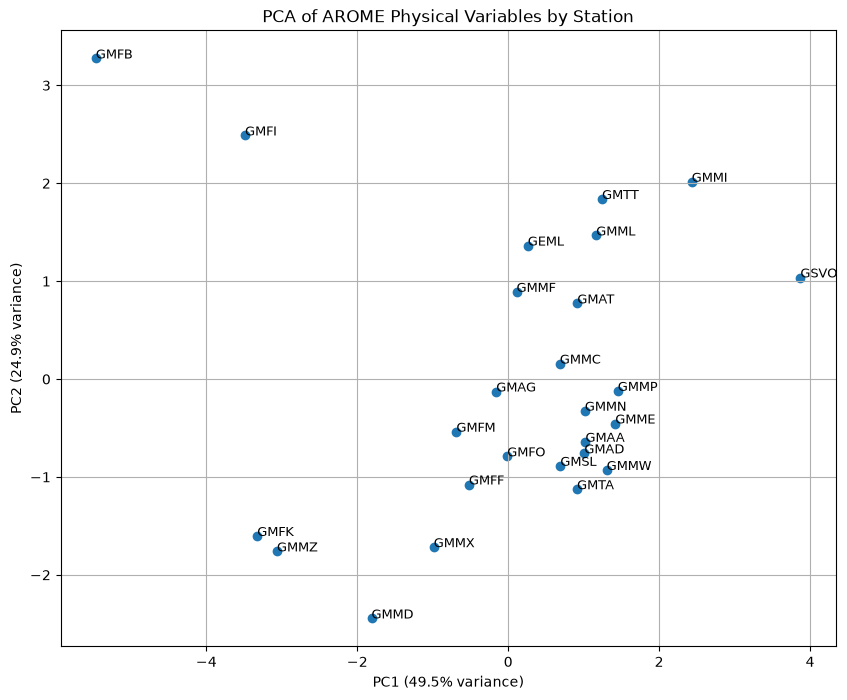

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA on AROME physical variables by station
features = [
    "t2m",
    "rh2m",
    "psurf",
    "arome_wind10_speed",
    "arome_wind950_speed",
    "pblh",
    "tke20m",
    "edr20m",
]

# One row per station with the mean of each feature
station_features = (
    df.groupby("icao")[features]
      .mean()
)

# Standardisation
X = StandardScaler().fit_transform(station_features)

# PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

pca_df = pd.DataFrame(
    coords,
    index=station_features.index,
    columns=["PC1", "PC2"]
)

# Plot PCA results
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

for station, row in pca_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        station,
        fontsize=9
    )

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)")
plt.title("PCA of AROME Physical Variables by Station")

plt.grid(True)
plt.show()

**Observation.** Stations separate into recognisable clusters along the
first two principal components, broadly tracking elevation and coastal
exposure (consistent with the elevation range identified in Section 4:
6 m&ndash;1,664 m). This heterogeneity is a reminder that the 26
stations are not interchangeable replicates of the same climatology;
which is precisely why every split in Section 7 is checked for **station
coverage**, not just row counts and gust rate: a split that happened to drop
a whole climatological cluster (e.g. all high-elevation stations) would
silently narrow the domain the model is evaluated on.

## 6. Seasonal Structure of Gust Occurrence

Section 3 showed that the yearly gust rate is non-monotonic. This section
resolves that at monthly resolution to check for a **seasonal cycle**, which
has direct consequences for how a chronological split should be validated:
if gusts cluster in specific months, a validation window that happens to
avoid those months will look artificially easy. `GSVO` is excluded from this
view given its discontinued post-2022 coverage (Section 3).

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

DATE_COL = "valid_time"
TARGET_COL = "has_gust"
STATION_COL = "station_id"

df = pd.read_csv("../data/cleaned/FINAL_PREPARED_DATA_2021_2025.csv")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df[TARGET_COL] = df[TARGET_COL].astype(bool)

df = df[df["icao"] != "GSVO"]

df["year_month"] = df[DATE_COL].dt.to_period("M")

monthly_stats = (
    df.groupby("year_month")
    .agg(n_samples=(TARGET_COL, "size"), n_gusts=(TARGET_COL, "sum"))
    .assign(gust_rate_pct=lambda x: 100 * x.n_gusts / x.n_samples)
)

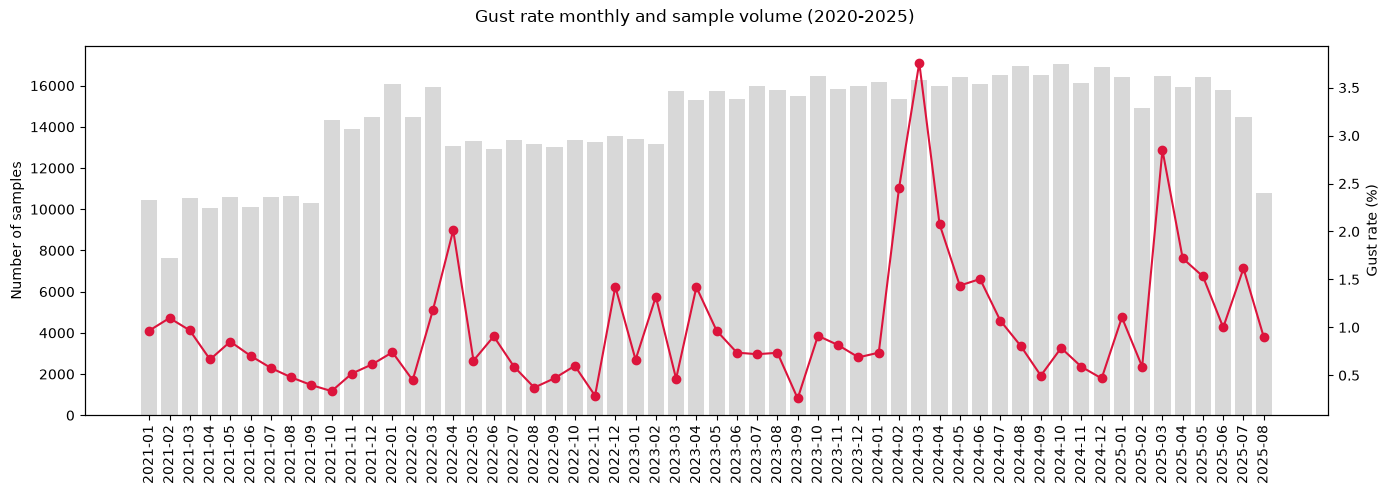

In [59]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly_stats.index.astype(str), monthly_stats.n_samples, alpha=0.3, color="gray", label="n_samples")
ax1.set_ylabel("Number of samples")
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly_stats.index.astype(str), monthly_stats.gust_rate_pct, color="crimson", marker="o", label="Gust rate (%)")
ax2.set_ylabel("Gust rate (%)")

fig.suptitle("Gust rate monthly and sample volume (2020-2025)")
fig.tight_layout()
plt.show()

**Observation.** The monthly series shows a clear, recurring
**late-winter/early-spring peak** (February&ndash;April) with rates rising
well above the yearly average, and a summer/autumn trough
(August&ndash;November) with rates below 0.5%. Critically, the amplitude of
the peak is not stable across years: it intensifies markedly in the most
recent two years (March 2024: 3.76%, March 2025: 2.85%) compared to earlier
peaks (~1.4% in 2022&ndash;2023). This mirrors the yearly figures from
Section 3 (0.81% in 2023 &rarr; 1.33% in 2024 &rarr; 1.44% in 2025) and shows
that the *year-level* increase is driven by a handful of intense
seasonal months rather than a uniform shift.

**Consequence for the split.** With only ~4.5 years of data, no
chronological split can give both validation and test a "typical" and
statistically stable sample of every peak season. This dataset has too
short a history to fully decouple **temporal ordering** (required to avoid
leakage) from **seasonal representativeness** (required for stable
validation metrics). The split adopted in Section 7 accepts this trade-off
explicitly rather than hiding it: it prioritizes leakage-free chronological
separation, and any gap in seasonal representativeness in validation is
compensated for by monitoring test performance **per month/season** rather
than as a single aggregate number, and by never using the validation split
itself to draw conclusions about seasonal robustness.

## 7. Final Split Design, Implementation, and Validation

### 7.1 Design decisions

Building on Sections 1&ndash;6, the split implemented in
`data/processed/splits/` follows three decisions, each traceable to a
specific finding above:

| Decision | Rationale | Evidence |
|---|---|---|
| **Split on `run_time`, never on `valid_time`** | Each forecast run (`run_time`) produces multiple rows at different lead times, all sharing the same NWP initial state. Splitting on `valid_time` (or randomly) would let rows from the *same* forecast run fall into different splits, leaking information about that run's atmospheric state across the train/val/test boundary. Splitting on `run_time` guarantees that **all lead times of a given cycle stay together**, which is the unit of independence for this forecasting problem. | Dataset schema: `run_time`, `valid_time`, `lead_time` are distinct columns; multiple `lead_time` values share a `run_time`. |
| **Chronological (non-random) split**, `train < 2024-01-01`, `2024-01-01 < val < 2025-01-01`, `test > 2025-01-01` | The task is an operational forecasting problem: at inference time the model only ever sees the past. A random split would leak future atmospheric patterns into training and overstate generalization. Year-aligned boundaries also keep each split's seasonal cycle count as whole as the data allows (train = 3 full years, val = 1 full year, test = the most recent partial year), which keeps the Section 6 seasonality discussion interpretable per split. | Sections 3 & 6: yearly/monthly volume and gust-rate structure. |
| **`GSVO` removed from the test split only** | `GSVO` reporting effectively stops being statistically meaningful after 2022 (208 / 35 / 223 samples in 2023 / 2024 / 2025 vs. 5,527 / 1,868 in 2021 / 2022, last observation 2025-04-04). Its train contribution (2021&ndash;2023) is still substantial and worth keeping; its 2025 contribution is too sparse and truncated mid-year to serve as a meaningful test signal, and would silently reduce the number of "active" test stations without adding useful evaluation power. It is *not* removed from train/val, where its coverage is comparatively normal. | Section 3: station &times; year crosstab and per-station coverage table. |

### 7.2 Reference implementation

The split itself is produced by a standalone script (kept outside this
notebook for reproducibility, e.g. `src/data/split_data.py`).

### 7.3 Loading and validating the produced splits

The cells below load the three Parquet files exactly as written by the
script and recompute summary statistics independently, as a **post-hoc
audit**, if these numbers didn't match what the script printed at
generation time, that would indicate a reproducibility problem.

In [94]:
from pathlib import Path
import pandas as pd

SPLIT_DIR = Path("../data/processed/splits")

train = pd.read_parquet(SPLIT_DIR / "train.parquet")
val = pd.read_parquet(SPLIT_DIR / "val.parquet")
test = pd.read_parquet(SPLIT_DIR / "test.parquet")

splits = {
    "train": train,
    "val": val,
    "test": test,
}

In [95]:
summary = []

total_samples = sum(len(df) for df in splits.values())

for name, df in splits.items():

    summary.append({
        "split": name,
        "samples": len(df),
        "% samples": 100 * len(df) / total_samples,
        "stations": df["icao"].nunique(),
        "gusts": int(df["has_gust"].sum()),
        "gust rate (%)": 100 * df["has_gust"].mean(),
        "start": df["run_time"].min().date(),
        "end": df["run_time"].max().date(),
    })

summary = pd.DataFrame(summary)

summary

,split,samples,% samples,stations,gusts,gust rate (%),start,end
0,train,491073,60.724430,26,4585,0.933670,2020-12-31,2023-12-31
1,val,196445,24.291726,26,2621,1.334216,2024-01-01,2024-12-31
2,test,121173,14.983844,25,1752,1.445867,2025-01-01,2025-08-24


**Validation.** The reloaded splits reproduce the expected shape:

- **Chronological ordering holds**: train ends 2023-12-31, val spans exactly
  2024, test starts 2025-01-01, no overlap, consistent with the
  `run_time` cutoffs.
- **Station coverage is preserved** in train (26) and val (26); test has 25
  stations, the expected effect of dropping `GSVO` there and there only.
- **Proportions land close to a 60/25/15 split** by row count
  (60.7% / 24.3% / 15.0%), which is smaller on the validation side and
  larger on train than a target 70/15/15 would be, a direct
  consequence of anchoring the split to full calendar years (Section 7.1)
  rather than to a fixed percentage. This trade-off was made deliberately:
  see the companion discussion on rebalancing towards 70/15/15 by shifting
  the `run_time` cutoffs, still constrained to preserve the leakage
  guarantee and to avoid moving the validation window into a period where
  it would either straddle or entirely miss the February&ndash;April
  gust peak identified in Section 6.


In [96]:
stats = []

for name, df in splits.items():

    stats.append({
        "split": name,
        "No gust": int((df["has_gust"] == 0).sum()),
        "Gust": int((df["has_gust"] == 1).sum()),
        "Positive rate (%)": round(100 * df["has_gust"].mean(), 3),
    })

pd.DataFrame(stats)

,split,No gust,Gust,Positive rate (%)
0,train,486488,4585,0.934
1,val,193824,2621,1.334
2,test,119421,1752,1.446


**Validation.** The gust rate increases monotonically across the three
splits (train: 0.934% &rarr; val: 1.334% &rarr; test: 1.446%), which is
expected and *not* a symptom of a broken split: it reflects the real
inter-annual gust-rate trend already documented in Sections 3 and 6
(2023's low 0.81% sitting inside train, 2024's higher 1.33% as val, and
2025's intensified spring peak dominating test). This asymmetry is exactly
why aggregate validation performance should be interpreted with the
seasonal caveat from Section 6.1 in mind, and why any model selection
decision made on `val` should be cross-checked against a walk-forward
temporal validation scheme before being taken as final, rather than trusted
as a single held-out number.


## Summary

The chronological split adopted for this project (`run_time`-based,
year-aligned boundaries, `GSVO` excluded from test only) is the direct
outcome of the evidence gathered above:

1. Gusts are rare and unevenly distributed across stations (Section 1) and
   months (Section 6), any split must be checked for both row-count
   balance and class/seasonal balance, not row-count balance alone.
2. Raw gust fields are unreliable at the station level (Section 2), which
   justifies relying on the pre-engineered `has_gust` label rather than
   re-deriving it here.
3. Station coverage is **not static**: reporting volume swings sharply for
   some stations (`GMFI`, `GMSL`) and one effectively drops out (`GSVO`
   after 2022) (Section 3), a fixed split boundary must account for this
   instead of assuming a stable panel of stations.
4. Metadata integrity issues (Section 4) can silently corrupt per-station
   statistics if not caught before they propagate into split design.
5. Splitting on `run_time` rather than `valid_time` is a **hard
   correctness requirement**, not a stylistic choice: it is the only way to
   keep all lead times of a forecast cycle on the same side of the
   train/val/test boundary, and is enforced with an assertion rather than
   left implicit.
6. The residual gust-rate asymmetry across splits (Section 7.3) is a known,
   documented consequence of real inter-annual variability, not an artifact
   to be "fixed" by reshuffling, and is flagged here so that we interpret validation metrics with
   that context in mind.
